<a href="https://colab.research.google.com/github/vastav03/Machine-Learning-Practical/blob/main/Logistic%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 import numpy as np  # numeric arrays
import pandas as pd  # organise data into a table
import matplotlib.pyplot as plt  # plot graphs
from sklearn.model_selection import train_test_split  # split data
from sklearn.preprocessing import StandardScaler  # scale features
from sklearn.linear_model import LogisticRegression  # the model class
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
from google.colab import files  # Colab's file-upload helper
uploaded = files.upload()  # opens a Choose File dialog; pick Social_Network_Ads.csv

df =pd.read_csv('Social_Network_Ads.csv')  # load the CSV into a DataFrame
df.head()  # show first 5 rows to check the data


Saving Social_Network_Ads.csv to Social_Network_Ads.csv


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


(400, 5)
Purchased
0    257
1    143
Name: count, dtype: int64


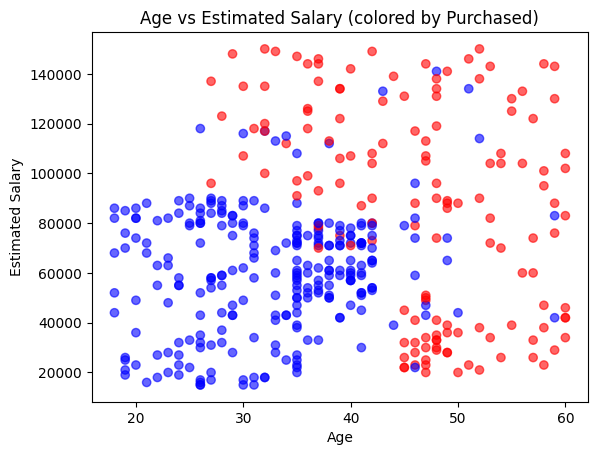

In [ ]:
print(df.shape)  # (rows, columns)
print(df['Purchased'].value_counts())  # how many 0s and 1s

plt.scatter(df['Age'], df['EstimatedSalary'],  # plot every user
            c=df['Purchased'], cmap='bwr', alpha=0.6)  # color by class (blue=0, red=1)
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.title('Age vs Estimated Salary (colored by Purchased)')
plt.show()


In [ ]:
X = df[['Age', 'EstimatedSalary']]  # input features
y = df['Purchased']  # output/target (0 or 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)  # 75% train, 25% test
print(X_train.shape, X_test.shape)


(300, 2) (100, 2)


In [ ]:
scaler = StandardScaler()  # create a scaler
X_train_scaled = scaler.fit_transform(X_train)  # learn mean/std from train, then scale it
X_test_scaled = scaler.transform(X_test)  # scale test data using the SAME mean/std
print(X_train_scaled[0])  # first scaled row


[ 0.58164944 -0.88670699]


In [ ]:
model = LogisticRegression(random_state=0)  # create an untrained model object
model.fit(X_train_scaled, y_train)  # train it: weights & bias learned here
print('Coefficients:', model.coef_)  # learned weights
print('Intercept:', model.intercept_)  # learned bias


Coefficients: [[2.07665837 1.11008221]]
Intercept: [-0.95217247]


In [ ]:
y_pred = model.predict(X_test_scaled)  # predict class for unseen test data
acc = accuracy_score(y_test, y_pred)  # fraction of correct predictions
cm = confusion_matrix(y_test, y_pred)  # TP/TN/FP/FN table
print('Accuracy:', acc)
print('Confusion Matrix:\n', cm)
print(classification_report(y_test, y_pred))  # precision, recall, f1-score


Accuracy: 0.89
Confusion Matrix:
 [[65  3]
 [ 8 24]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



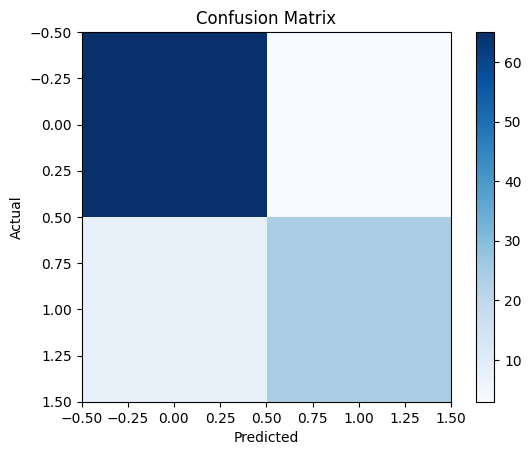

In [ ]:
plt.imshow(cm, cmap='Blues')  # visualise the confusion matrix
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.colorbar(); plt.show()


In [ ]:
new_customer = pd.DataFrame([[45, 110000]],  # Age=45, Salary=110000
                            columns=['Age', 'EstimatedSalary'])
new_scaled = scaler.transform(new_customer)  # scale using the SAME scaler as training
pred = model.predict(new_scaled)  # 0 = No, 1 = Yes
prob = model.predict_proba(new_scaled)  # [P(No), P(Yes)]
print('Prediction:', pred[0])
print('Probability [No, Yes]:', prob[0])


Prediction: 1
Probability [No, Yes]: [0.14651851 0.85348149]
